# Functions to Generate Season 3 PWHL Attendance Dataset

[PWHL Data reference](https://github.com/IsabelleLefebvre97/PWHL-Data-Reference)



In [43]:
pip install requests

In [44]:
import pandas as pd

In [45]:
import requests
def get_game_summary_df_from_id(game_id):
  game_summary_response = requests.get("https://lscluster.hockeytech.com/feed/index.php?feed=gc&tab=gamesummary&game_id="+str(game_id)+"&key=446521baf8c38984&client_code=pwhl")
  if game_summary_response.status_code != 200:
    return None

  game_summary_data = game_summary_response.json()
  game_summary_json = game_summary_data["GC"]["Gamesummary"]["meta"]

  # Load the JSON file into a DataFrame
  game_summary_df = pd.json_normalize(game_summary_json)

  game_summary_df_attendance_df = game_summary_df[["id","season_id", "home_team", "visiting_team", "game_number", "attendance", "location", "date_played"]]
  return game_summary_df_attendance_df

In [46]:
team_name_map = {
    1: "Boston Fleet",
    2: "Minnesota Frost",
    3: "Montréal Victoire",
    4: "New York Sirens",
    5: "Ottawa Charge",
    6: "Toronto Sceptres",
    8: "Seattle Torrent",
    9: "Vancouver Goldeneyes",
}

primary_location_name_map = {
    29: "Grand Casino Arena",
    30: "Pacific Coliseum",
    1: "TD Place",
    3: "Tsongas Center",
    8: "Place Bell",
    17: "Coca-Cola Coliseum",
    16: "Prudential Center",
    21: "Climate Pledge Arena"
}

special_location_name_map = {
    23: "Ball Arena",
    28: "Agganis Arena",
    20: "Canadian Tire Centre"
}

location_name_map = primary_location_name_map | special_location_name_map

season_id_map = {
    8: "2025-2026 regular season",
    9: "2026 playoffs"
}


def format_game_summary_df(game_summary_df):
  game_summary_df_formatted = game_summary_df.copy()
  game_summary_df_formatted["id"] = game_summary_df_formatted["id"].astype(int)
  game_summary_df_formatted["home_team"] = game_summary_df_formatted["home_team"].astype(int)
  game_summary_df_formatted["visiting_team"] = game_summary_df_formatted["visiting_team"].astype(int)
  game_summary_df_formatted["season_id"] = game_summary_df_formatted["season_id"].astype(int)
  game_summary_df_formatted["game_number"] = game_summary_df_formatted["game_number"].astype(int)
  game_summary_df_formatted["attendance"] = game_summary_df_formatted["attendance"].astype(int)
  game_summary_df_formatted["location"] = game_summary_df_formatted["location"].astype(int)
  game_summary_df_formatted["home_team_name"] = game_summary_df_formatted["home_team"].map(team_name_map)
  game_summary_df_formatted["visiting_team_name"] = game_summary_df_formatted["visiting_team"].map(team_name_map)
  game_summary_df_formatted["location_name"] = game_summary_df_formatted["location"].map(location_name_map)
  return game_summary_df_formatted


In [47]:
def get_attendance_data_between_ids_inclusive_exclusive(start_game_id, end_game_id):
  game_dfs = []
  for game_id in range(start_game_id, end_game_id):
    temp_df = get_game_summary_df_from_id(game_id)
    if temp_df is not None:
      game_dfs.append(temp_df)

  all_games = pd.concat(game_dfs, ignore_index=True)
  return format_game_summary_df(all_games)

# Generate S3 Regular Season Dataset
- s3_regular_season_attendance_data = attendance data from all 120 regular season games
- s3_regular_season_primary_venue_attendance_data = attendance data from regular season games played at primary venues
- s3_regular_season_special_venue_attendance_data = attendance data from regular season games played at "special" venues, including takeover games or one-of games like MSG

In [48]:
S3_FIRST_GAME_ID = 210
S3_LAST_GAME_ID = 329

In [49]:
s3_regular_season_attendance_data = get_attendance_data_between_ids_inclusive_exclusive(S3_FIRST_GAME_ID, S3_LAST_GAME_ID + 1)

In [50]:
len(s3_regular_season_attendance_data)

120

In [51]:
s3_regular_season_primary_venue_attendance_data = s3_regular_season_attendance_data[
    s3_regular_season_attendance_data["location"].isin(primary_location_name_map)
]

s3_regular_season_special_venue_attendance_data = s3_regular_season_attendance_data[
    ~s3_regular_season_attendance_data["location"].isin(primary_location_name_map)
]

In [52]:
s3_regular_season_primary_venue_attendance_data.to_csv("s3_regular_season_primary_venue_attendance_data.csv")

In [53]:
s3_regular_season_special_venue_attendance_data.to_csv("s3_regular_season_special_venue_attendance_data.csv")

In [54]:
s3_regular_season_attendance_data.to_csv("s3_regular_season_attendance_data.csv")

# Generate Playoffs Dataset

In [55]:
S3_PLAYOFFS_FIRST_GAME_ID = 338
S3_PLAYOFFS_LAST_GAME_ID = 351
# NOTE - GAME 346 IS MISSING

In [56]:
s3_playoffs_attendance_data = get_attendance_data_between_ids_inclusive_exclusive(S3_PLAYOFFS_FIRST_GAME_ID, S3_PLAYOFFS_LAST_GAME_ID + 1)

In [57]:
s3_playoffs_attendance_data

,id,season_id,home_team,visiting_team,game_number,attendance,location,date_played,home_team_name,visiting_team_name,location_name
0,338,9,1,5,1,4285,3,2026-04-30,Boston Fleet,Ottawa Charge,Tsongas Center
1,339,9,1,5,3,6017,3,2026-05-02,Boston Fleet,Ottawa Charge,Tsongas Center
2,340,9,3,2,2,9364,8,2026-05-02,Montréal Victoire,Minnesota Frost,Place Bell
3,341,9,3,2,4,7530,8,2026-05-05,Montréal Victoire,Minnesota Frost,Place Bell
4,342,9,2,3,6,6516,29,2026-05-07,Minnesota Frost,Montréal Victoire,Grand Casino Arena
5,343,9,5,1,5,13112,20,2026-05-08,Ottawa Charge,Boston Fleet,Canadian Tire Centre
6,344,9,5,1,7,11297,20,2026-05-10,Ottawa Charge,Boston Fleet,Canadian Tire Centre
7,345,9,2,3,8,5312,29,2026-05-08,Minnesota Frost,Montréal Victoire,Grand Casino Arena
8,347,9,3,2,10,6104,8,2026-05-12,Montréal Victoire,Minnesota Frost,Place Bell
9,348,9,5,3,13,16894,20,2026-05-18,Ottawa Charge,Montréal Victoire,Canadian Tire Centre


In [58]:
s3_playoffs_attendance_data.to_csv("pwhl_s3_playoffs_attendance_data.csv")

In [59]:
s3_regular_and_playoffs_attendance_data = pd.concat([s3_regular_season_attendance_data, s3_playoffs_attendance_data])

In [60]:
len(s3_regular_and_playoffs_attendance_data)

133

In [61]:
s3_regular_and_playoffs_attendance_data.to_csv("s3_regular_and_playoffs_attendance_data.csv")

# Season 3 Regular Season Average Attendance By Venue And Home Team

In [62]:
average_attendance_by_location = s3_regular_season_primary_venue_attendance_data.groupby('location_name')['attendance'].mean().reset_index()
print(average_attendance_by_location)

          location_name    attendance
0  Climate Pledge Arena  12875.461538
1    Coca-Cola Coliseum   8379.583333
2    Grand Casino Arena   8142.846154
3      Pacific Coliseum  11234.692308
4            Place Bell   9270.583333
5     Prudential Center   4018.666667
6              TD Place   7382.000000
7        Tsongas Center   4885.250000


In [63]:
average_attendance_by_team = s3_regular_season_attendance_data.groupby('home_team_name')['attendance'].mean().reset_index()
print(average_attendance_by_team)

         home_team_name    attendance
0          Boston Fleet   6530.666667
1       Minnesota Frost   8573.800000
2     Montréal Victoire  10661.066667
3       New York Sirens   6131.466667
4         Ottawa Charge   9138.200000
5       Seattle Torrent  12599.933333
6      Toronto Sceptres   9657.400000
7  Vancouver Goldeneyes  11140.600000


In [64]:
average_attendance_by_location.to_csv("primary_venue_average_attendance_by_location.csv")

In [65]:
average_attendance_by_team.to_csv("average_attendance_by_home_team.csv")

# Import Arena Capacity Data From GDrive

In [66]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
# s3_arena_capacities_df = pd.read_csv("s3_arena_capacities.csv")
s3_arena_capacities_df = pd.read_csv('/content/drive/My Drive/arena characteristics/s3_arena_capacities.csv')

s3_arena_capacities_df.head()

,location_name,city,capacity
0,Climate Pledge Arena,Seattle,17151
1,Coca-Cola Coliseum,Toronto,8140
2,Grand Casino Arena,Minnesota,18064
3,Pacific Coliseum,Vancouver,15041
4,Place Bell,Montréal,10172


In [68]:
all_arena_capacities_df = pd.read_csv('/content/drive/My Drive/arena characteristics/all_arena_capacities.csv')
all_arena_capacities_df.head()

,location_name,city,capacity
0,Climate Pledge Arena,Seattle,17151
1,Coca-Cola Coliseum,Toronto,8140
2,Grand Casino Arena,Minnesota,18064
3,Pacific Coliseum,Vancouver,15041
4,Place Bell,Montréal,10172


In [69]:
s4_arena_capacities_df = pd.read_csv('/content/drive/My Drive/arena characteristics/s4_arena_capacities.csv')

s4_arena_capacities_df.head()

,location_name,city,capacity,is_expansion_team
0,Climate Pledge Arena,Seattle,17151,False
1,Coca-Cola Coliseum,Toronto,8140,False
2,Grand Casino Arena,Minnesota,18064,False
3,Pacific Coliseum,Vancouver,15041,False
4,Place Bell,Montréal,10172,False


In [105]:
s1_arena_capacities_df = pd.read_csv('/content/drive/My Drive/arena characteristics/s1_arena_capacities.csv')

s1_arena_capacities_df.head()

,location_name,city,capacity
0,Mattamy Athletic Centre,Toronto,2600
1,Grand Casino Arena,Minnesota,18064
2,Verdun Auditorium,Montréal,4000
3,Total Mortgage Arena,New York,10000
4,TD Place,Ottawa,8585


## Season 3 Regular Season Average Attendance By Venue Vs Capacity


In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_arena_average_attendance_vs_capacity(average_attendance_by_location_df, arena_capacities_df, color=None):
    # Merge average attendance with arena capacities and city names
    merged_df_with_city = pd.merge(average_attendance_by_location_df, arena_capacities_df[['location_name', 'capacity', 'city']], on='location_name', how='left')

    # Create a combined label for location and city
    merged_df_with_city['display_label'] = merged_df_with_city.apply(lambda row: f"{row['location_name']} ({row['city']})", axis=1)

    # Sort the DataFrame by attendance for better visualization
    sorted_merged_df = merged_df_with_city.sort_values(by='attendance', ascending=False)

    # Create the figure and axes
    fig, ax = plt.subplots(figsize=(14, 8))

    # Plot capacity bars (background)
    ax.bar(
        sorted_merged_df['display_label'],
        sorted_merged_df['capacity'],
        color='lightgray',
        label='Arena Capacity',
        zorder=1 # Ensure capacity bars are behind
    )

    # Plot attendance bars on top
    sns.barplot(
        x='display_label',
        y='attendance',
        data=sorted_merged_df,
        color= color if color is not None else 'skyblue',
        label='Average Attendance',
        ax=ax, # Specify the axes
        zorder=2 # Ensure attendance bars are in front
    )

    # Get the BarContainer for the attendance bars specifically
    # ax.containers holds a list of BarContainer objects, one for each bar plot call
    # The last one should be the attendance bars from sns.barplot
    attendance_bars_container = ax.containers[-1]

    # Add attendance numbers on top of the attendance bars only
    for bar in attendance_bars_container:
        yval = bar.get_height()
        if yval > 0: # Ensure we are labeling actual attendance bars
            ax.text(
                bar.get_x() + bar.get_width()/2,
                yval + 50, # Slightly above the bar
                int(yval),
                ha='center',
                va='bottom',
                fontsize=10
            )

    ax.set_xlabel('Arena Location (City)', fontsize=14)
    ax.set_ylabel('Count', fontsize=14)
    ax.set_title('Average Attendance vs. Arena Capacity by Location', fontsize=16)

    # Correct way to set x-ticks and x-tick labels
    ax.set_xticks(range(len(sorted_merged_df['display_label'])))
    ax.set_xticklabels(sorted_merged_df['display_label'], rotation=45, ha='right', fontsize=12)

    ax.tick_params(axis='y', labelsize=12)
    ax.legend(fontsize=12)
    plt.tight_layout()
    return fig

# Season 3 Regular Season Attendances By Venue

In [72]:
df_filtered = s3_regular_season_primary_venue_attendance_data[s3_regular_season_primary_venue_attendance_data["location_name"] == "Prudential Center"]

In [73]:
df_filtered

,id,season_id,home_team,visiting_team,game_number,attendance,location,date_played,home_team_name,visiting_team_name,location_name
7,217,8,4,9,8,3517,16,2025-11-29,New York Sirens,Vancouver Goldeneyes,Prudential Center
18,228,8,4,1,19,1884,16,2025-12-17,New York Sirens,Boston Fleet,Prudential Center
22,232,8,4,6,23,3517,16,2025-12-21,New York Sirens,Toronto Sceptres,Prudential Center
32,242,8,4,9,33,2735,16,2025-12-31,New York Sirens,Vancouver Goldeneyes,Prudential Center
33,243,8,4,3,34,3513,16,2026-01-02,New York Sirens,Montréal Victoire,Prudential Center
46,256,8,4,2,47,4244,16,2026-01-16,New York Sirens,Minnesota Frost,Prudential Center
50,260,8,4,5,51,2759,16,2026-01-20,New York Sirens,Ottawa Charge,Prudential Center
61,271,8,4,3,62,3488,16,2026-02-26,New York Sirens,Montréal Victoire,Prudential Center
68,278,8,4,1,69,3765,16,2026-03-05,New York Sirens,Boston Fleet,Prudential Center
69,279,8,4,5,70,8264,16,2026-03-08,New York Sirens,Ottawa Charge,Prudential Center


In [74]:
import matplotlib.pyplot as plt

def plot_arena_attendance_vs_capacity(arena_name, s3_regular_season_primary_venue_attendance_data, arena_capacities_df, colors=None, show_playoff_shading=False):

    weekday_color = colors[0] if colors is not None else 'skyblue'
    weekend_color = colors[1] if colors is not None else 'lightcoral'
    # Filter for games from the specified arena
    arena_games_df = s3_regular_season_primary_venue_attendance_data[s3_regular_season_primary_venue_attendance_data['location_name'] == arena_name].copy()

    if arena_games_df.empty:
        print(f"No data found for {arena_name}.")
        # Return None for fig, ax, and legend_handles if no data
        return None, None, []

    # Convert 'date_played' to datetime objects to get day of the week
    arena_games_df['date_played_dt'] = pd.to_datetime(arena_games_df['date_played'])

    # Sort by attendance in descending order
    arena_games_df_sorted = arena_games_df.sort_values(by='attendance', ascending=False)

    # Get arena capacity
    arena_capacity = arena_capacities_df[arena_capacities_df['location_name'] == arena_name]['capacity'].iloc[0]

    # Create a list of game labels for the x-axis using date_played and day of week
    game_labels = [f"{dt.strftime('%Y-%m-%d')} ({dt.strftime('%a')})" for dt in arena_games_df_sorted['date_played_dt']]

    # Determine colors based on weekday/weekend (Friday now included in weekend)
    # Monday=0, Sunday=6. Fri=4. So, dayofweek >= 4 includes Friday, Saturday, Sunday.
    bar_colors = [weekend_color if day_dt.dayofweek >= 4 else weekday_color for day_dt in arena_games_df_sorted['date_played_dt']]

    # Determine hatch patterns for playoff games (season_id == 9) only if show_playoff_shading is True
    hatch_patterns = ['///' if sid == 9 else None for sid in arena_games_df_sorted['season_id']] if show_playoff_shading else [None] * len(arena_games_df_sorted)

    fig, ax = plt.subplots(figsize=(12, 7))

    # Plot capacity bars first (as background)
    # Removed 'label' from here to prevent implicit legend creation
    ax.bar(
        game_labels,
        [arena_capacity] * len(arena_games_df_sorted),
        color='lightgray',
        zorder=1 # Ensure capacity bars are behind
    )

    # Plot attendance bars on top with conditional coloring and hatching
    attendance_bars = ax.bar(
        game_labels,
        arena_games_df_sorted['attendance'],
        color=bar_colors,
        hatch=hatch_patterns,
        zorder=2 # Ensure attendance bars are in front
    )

    # Add attendance numbers on top of the bars
    for bar in attendance_bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom', fontsize=10)

    ax.set_xlabel('Date Played (Day of Week)', fontsize=16)
    ax.set_ylabel('Attendance / Capacity', fontsize=16)
    ax.set_title(f'{arena_name} Game Attendance vs. Capacity', fontsize=16)
    ax.set_xticks(range(len(arena_games_df_sorted)))
    ax.set_xticklabels(game_labels, rotation=45, ha='right', fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # Create custom legend handles for weekday/weekend and playoff games
    capacity_patch = plt.matplotlib.patches.Patch(color='lightgray', label=f'{arena_name} Capacity')
    weekday_patch = plt.matplotlib.patches.Patch(color=weekday_color, label='Weekday Attendance')
    weekend_patch = plt.matplotlib.patches.Patch(color=weekend_color, label='Weekend Attendance (incl. Friday)')

    legend_handles = [capacity_patch, weekday_patch, weekend_patch]
    if show_playoff_shading:
        playoff_patch = plt.matplotlib.patches.Patch(facecolor='gray', hatch='///', label='Playoff Game') # New patch for playoff games
        legend_handles.append(playoff_patch)

    return fig, ax, legend_handles

# Plot and Save Graphs

In [75]:
import os

# Define your directory name or path
os.makedirs("/content/graphs", exist_ok=True)

## Average Attendance Vs Capacity

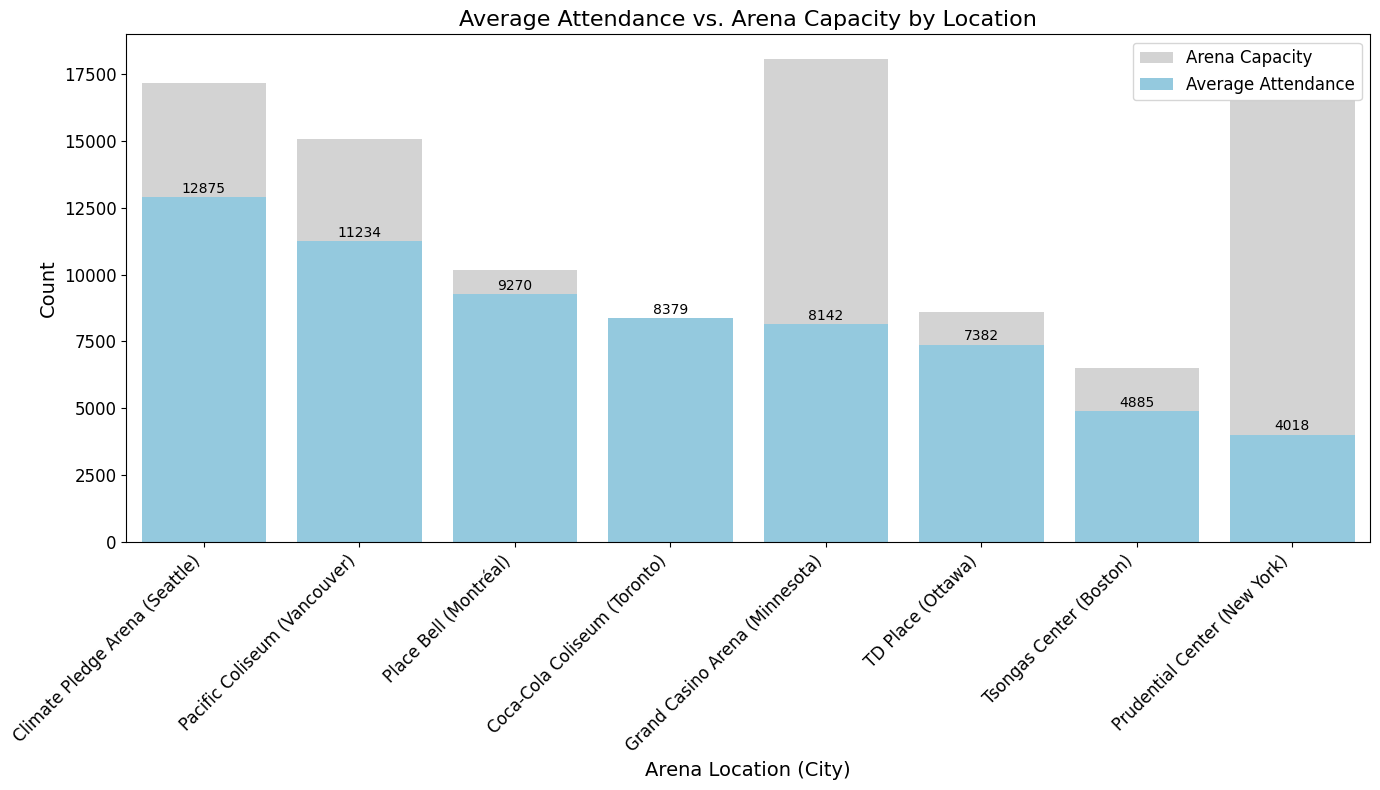

In [76]:
fig = plot_arena_average_attendance_vs_capacity(average_attendance_by_location, s3_arena_capacities_df)
fig.savefig('graphs/primary_venue_averages_vs_capacity.png', dpi=300, bbox_inches='tight')

## Attendances Per Game For Primary Venues

In [77]:
location_name_color_map = {
    "Grand Casino Arena" : ("MediumPurple", "Indigo"),
    "Pacific Coliseum": ("Peru", "DarkBlue"),
    "TD Place": ("Gold", "Red"),
    "Tsongas Center": ("MediumTurquoise", "DarkGreen"),
    "Place Bell": ("Navy","DarkRed"),
    "Coca-Cola Coliseum": ("Gold", "RoyalBlue"),
    "Prudential Center": ("orange", "LightSeaGreen"),
    "Climate Pledge Arena": ("MediumTurquoise", "Teal"),
    "Canadian Tire Centre": ("Gold", "Red"),
    "Agganis Arena": ("MediumTurquoise", "DarkGreen"),
    "Little Caesars Arena": ("red", "red"),
    "SAP Center": ("DodgerBlue", "DodgerBlue"),
    "T-Mobile Arena": ("OliveDrab", "OliveDrab"),
    "TD Coliseum": ("Gold", "Gold"),
}

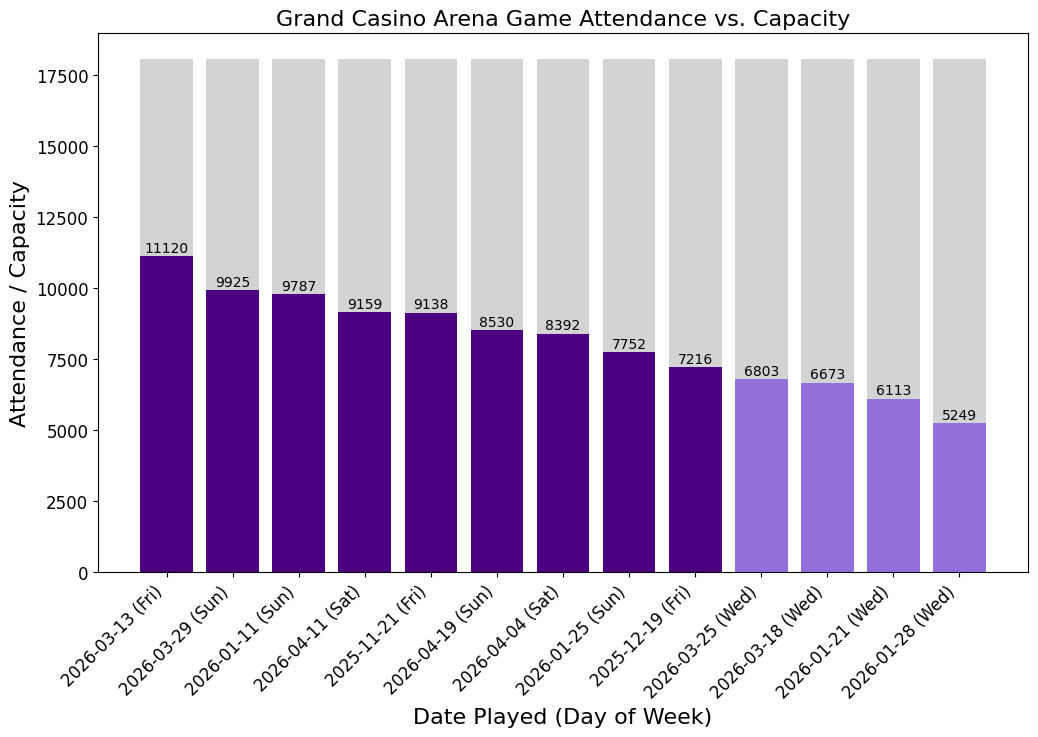

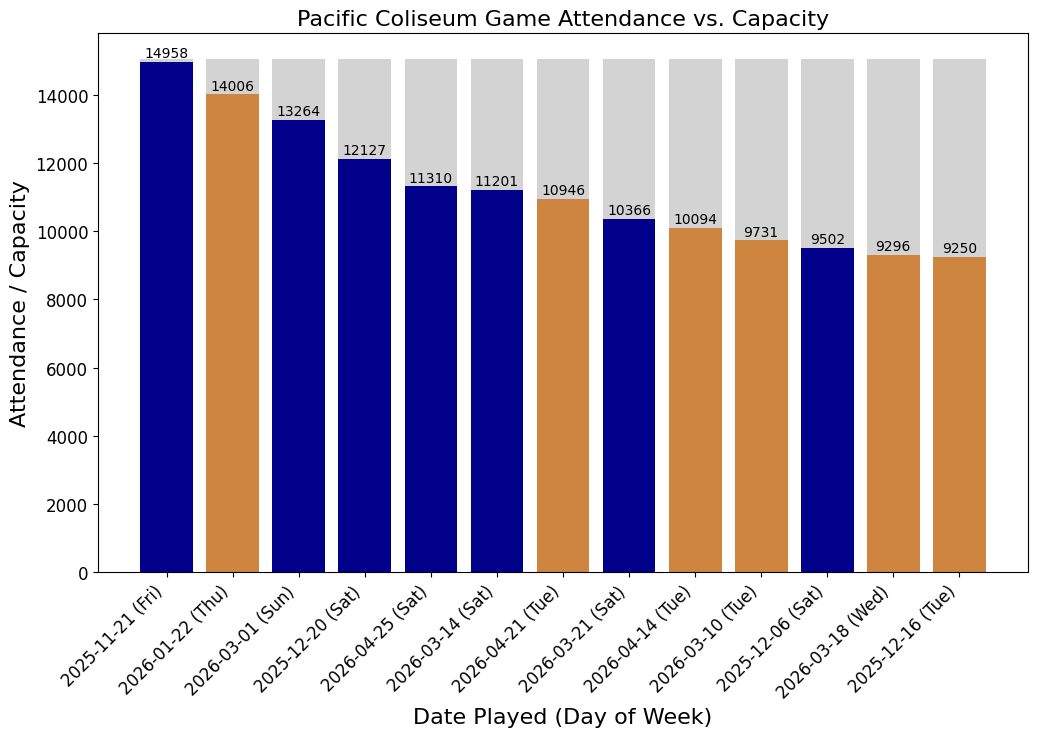

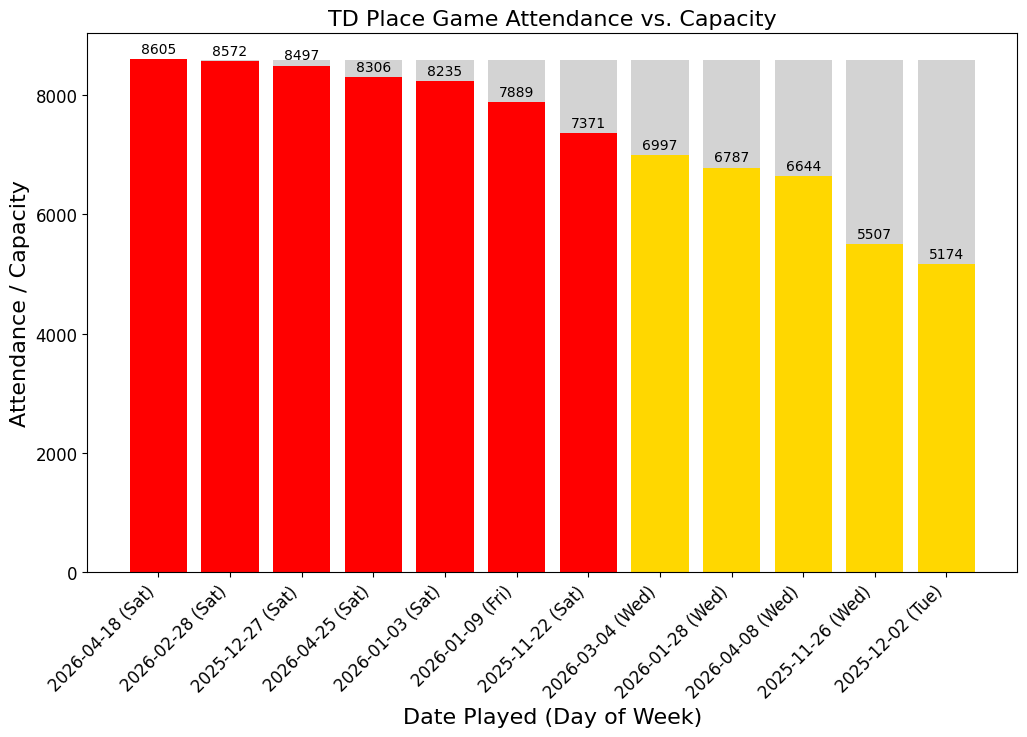

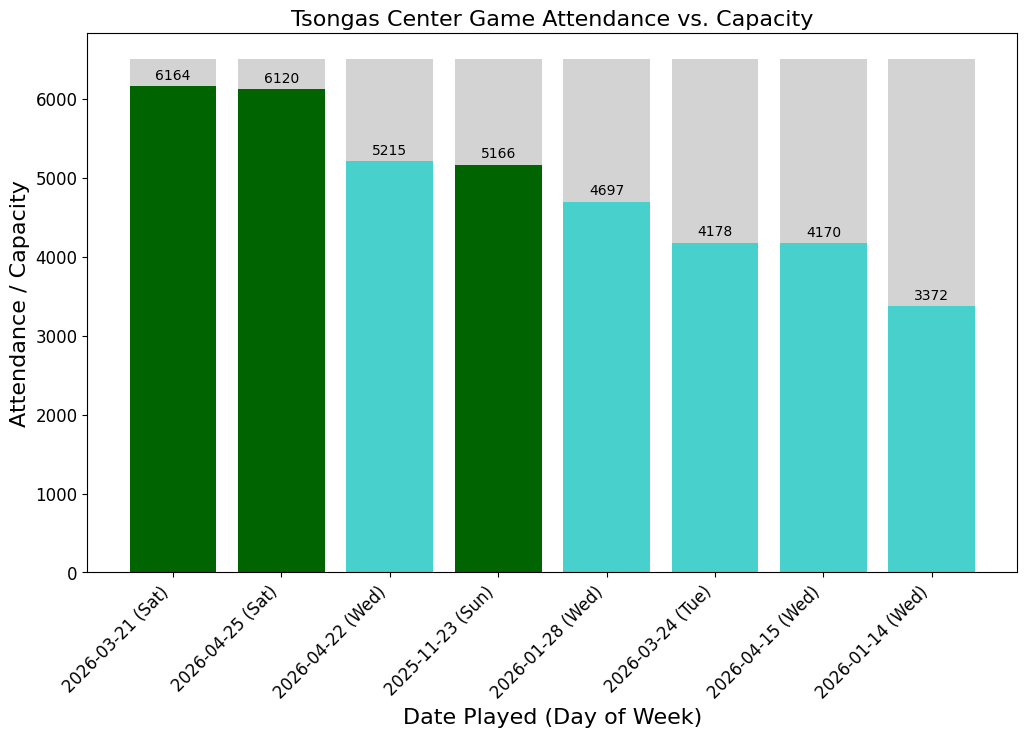

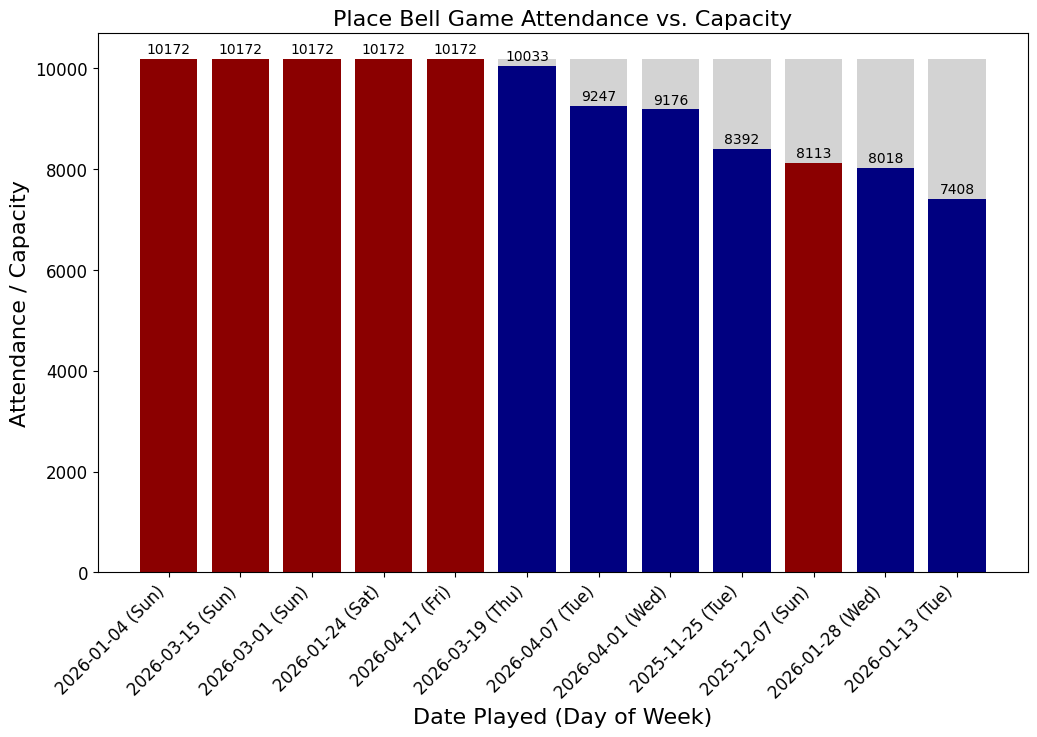

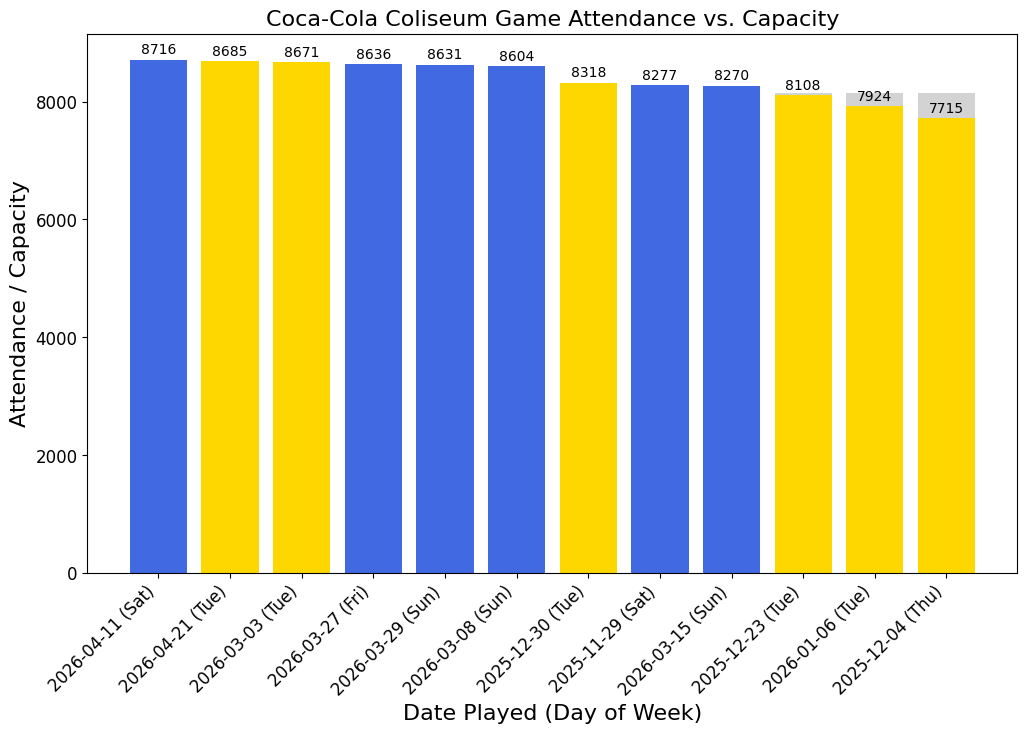

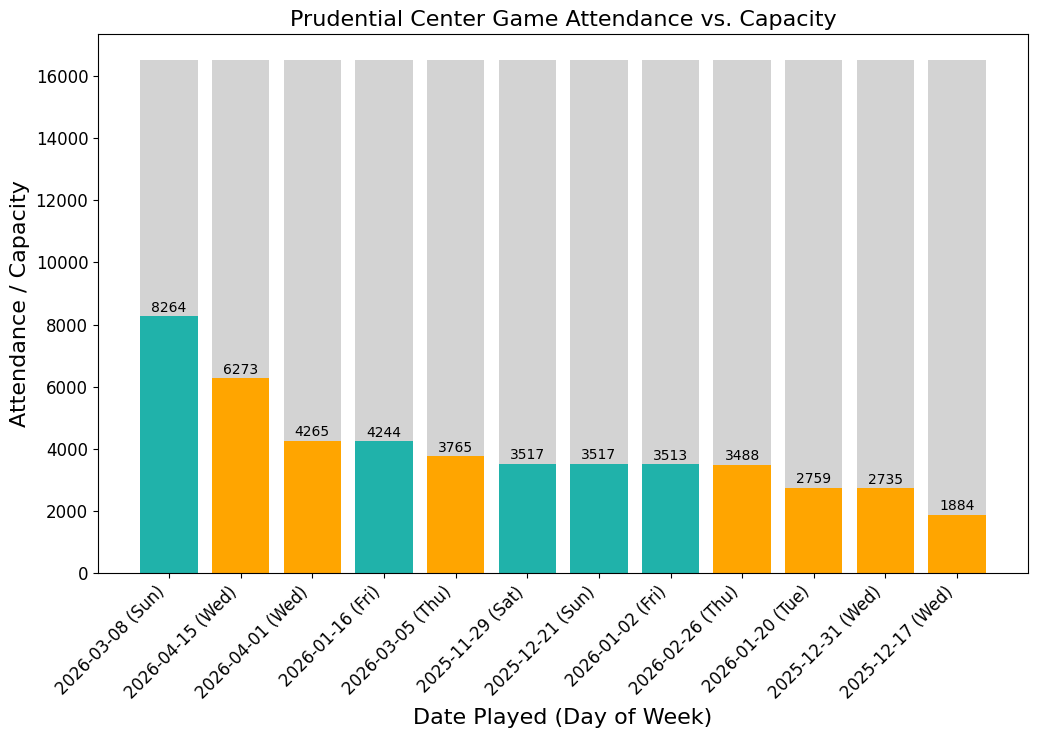

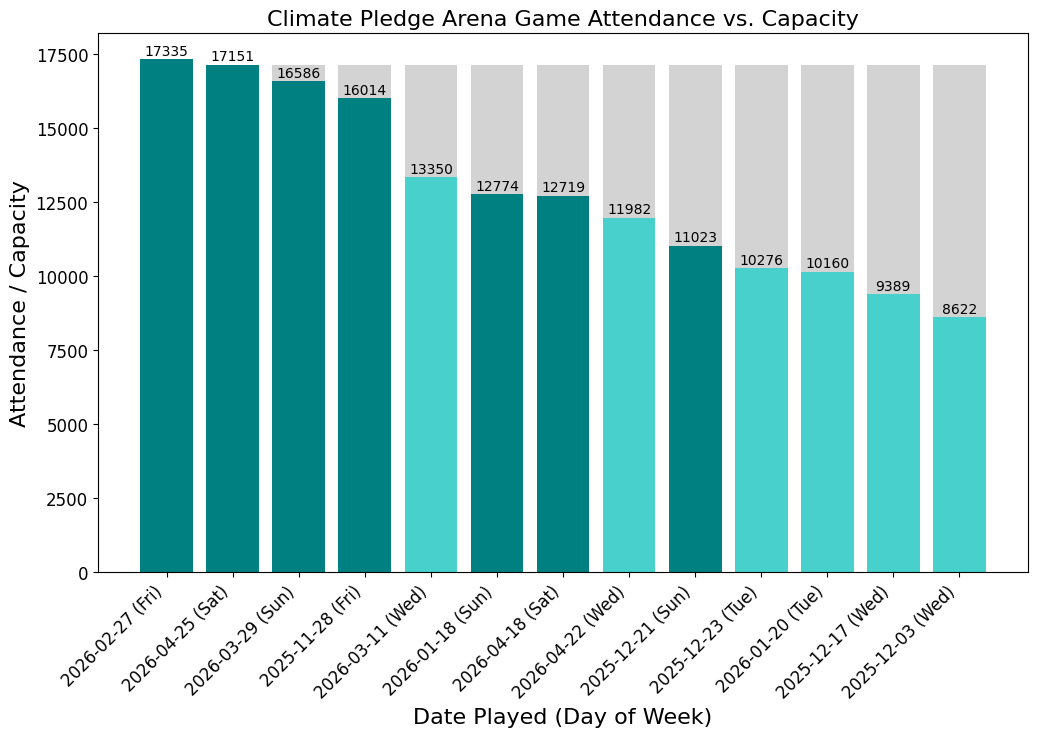

In [78]:
for arena_name in primary_location_name_map.values():
    fig, _, _ = plot_arena_attendance_vs_capacity(arena_name, s3_regular_season_primary_venue_attendance_data, all_arena_capacities_df, location_name_color_map[arena_name], show_playoff_shading=False)
    fig.savefig('graphs/'+arena_name+'.png', dpi=300, bbox_inches='tight')

## Canadian Tire Centre

In [79]:
ctc_games = s3_regular_and_playoffs_attendance_data[s3_regular_and_playoffs_attendance_data["location_name"] == "Canadian Tire Centre"]

In [80]:
ctc_games

,id,season_id,home_team,visiting_team,game_number,attendance,location,date_played,home_team_name,visiting_team_name,location_name
72,282,8,5,3,73,17114,20,2026-04-03,Ottawa Charge,Montréal Victoire,Canadian Tire Centre
5,343,9,5,1,5,13112,20,2026-05-08,Ottawa Charge,Boston Fleet,Canadian Tire Centre
6,344,9,5,1,7,11297,20,2026-05-10,Ottawa Charge,Boston Fleet,Canadian Tire Centre
9,348,9,5,3,13,16894,20,2026-05-18,Ottawa Charge,Montréal Victoire,Canadian Tire Centre
10,349,9,5,3,14,12362,20,2026-05-20,Ottawa Charge,Montréal Victoire,Canadian Tire Centre


In [81]:
ctc_games['attendance'].mean()

np.float64(14155.8)

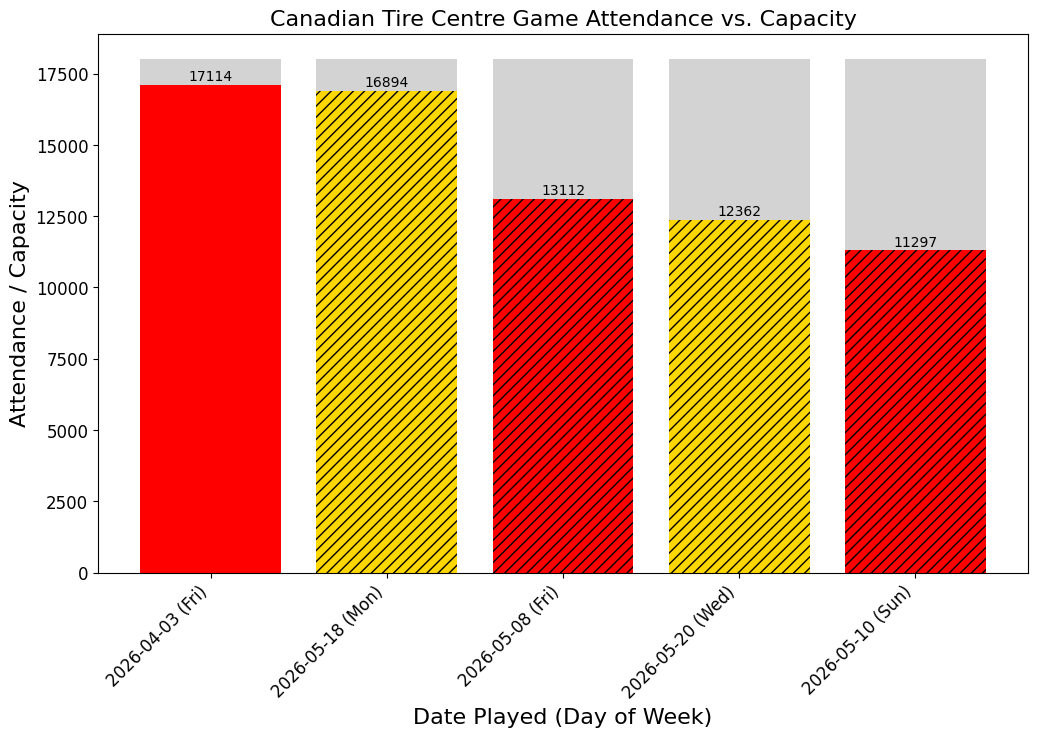

In [82]:
fig,_,_= plot_arena_attendance_vs_capacity("Canadian Tire Centre", ctc_games, all_arena_capacities_df, location_name_color_map["Canadian Tire Centre"], show_playoff_shading=True)

In [83]:
fig.savefig('graphs/Canadian Tire Centre.png', dpi=300, bbox_inches='tight')

## Agganis Arena

In [84]:
agganis_games = s3_regular_season_attendance_data[s3_regular_season_attendance_data["location_name"] == "Agganis Arena"]

In [85]:
agganis_games

,id,season_id,home_team,visiting_team,game_number,attendance,location,date_played,home_team_name,visiting_team_name,location_name
10,220,8,1,9,11,3516,28,2025-12-03,Boston Fleet,Vancouver Goldeneyes,Agganis Arena
15,225,8,1,2,16,5338,28,2025-12-07,Boston Fleet,Minnesota Frost,Agganis Arena
40,250,8,1,8,41,6003,28,2026-01-07,Boston Fleet,Seattle Torrent,Agganis Arena
79,289,8,1,6,80,6095,28,2026-03-17,Boston Fleet,Toronto Sceptres,Agganis Arena


In [86]:
agganis_games['attendance'].mean()

np.float64(5238.0)

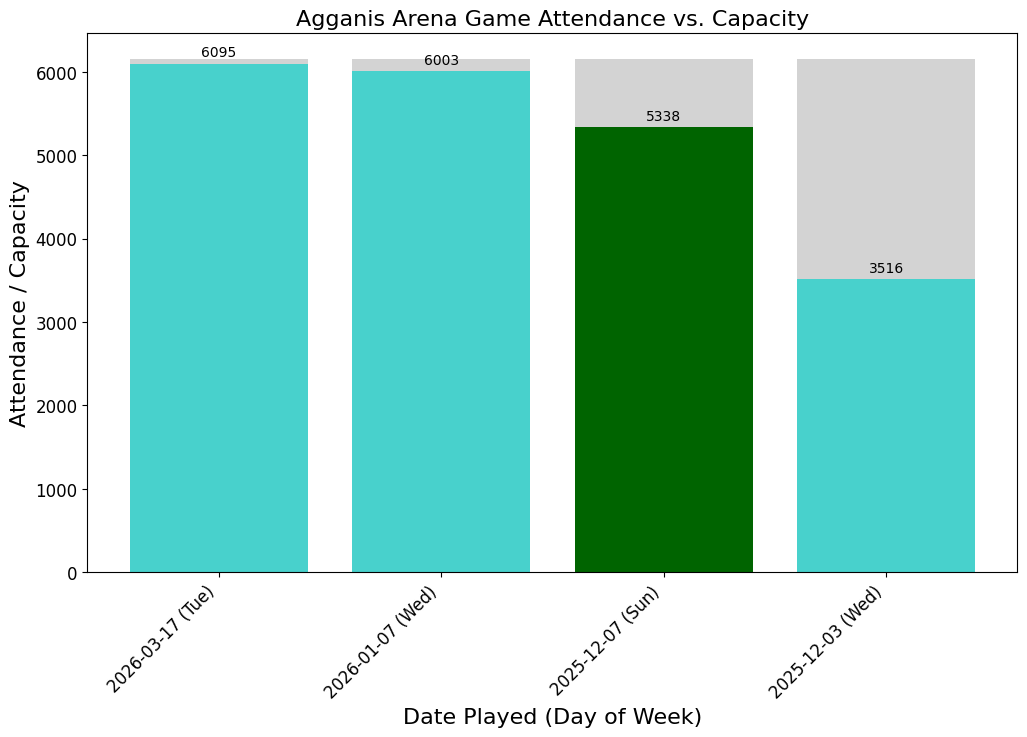

In [88]:
fig,_,_ = plot_arena_attendance_vs_capacity("Agganis Arena", agganis_games, all_arena_capacities_df, location_name_color_map["Agganis Arena"], show_playoff_shading=False)

In [89]:
fig.savefig('graphs/Agganis Arena.png', dpi=300, bbox_inches='tight')

## Arena Capacities


In [90]:
s4_arena_capacities_df

,location_name,city,capacity,is_expansion_team
0,Climate Pledge Arena,Seattle,17151,False
1,Coca-Cola Coliseum,Toronto,8140,False
2,Grand Casino Arena,Minnesota,18064,False
3,Pacific Coliseum,Vancouver,15041,False
4,Place Bell,Montréal,10172,False
5,Prudential Center,New York,16514,False
6,Canadian Tire Centre,Ottawa,18000,False
7,Agganis Arena,Boston,6150,False
8,SAP Center,San Jose,17435,True
9,T-Mobile Arena,Las Vegas,17500,True


In [91]:
s4_arena_capacities_df.iloc[5]["is_expansion_team"]

np.False_

In [92]:
import matplotlib.pyplot as plt

def plot_capacities(capacities_df, title='Primary Venue Capacities 2025-2026', show_expansion_teams=False):
    # Prepare data for plotting
    capacity_df = capacities_df.copy()

    # Map colors based on the second color in the tuple from location_name_color_map
    capacity_df['color'] = capacity_df['location_name'].map(lambda x: location_name_color_map.get(x, ('gray', 'lightgray'))[1])

    # Create a combined label for location and city
    capacity_df['display_label'] = capacity_df.apply(lambda row: f"{row['location_name']} ({row['city']})", axis=1)

    # Sort by capacity for better visualization
    capacity_df_sorted = capacity_df.sort_values(by='capacity', ascending=False)

    # Determine hatch patterns based on show_expansion_teams and 'is_expansion_team' column
    hatch_patterns = [None] * len(capacity_df_sorted)
    if show_expansion_teams and 'is_expansion_team' in capacity_df_sorted.columns:
        hatch_patterns = ['///' if row['is_expansion_team'] else None for _, row in capacity_df_sorted.iterrows()]

    fig, ax = plt.subplots(figsize=(12, 7))

    bars = ax.bar(
        capacity_df_sorted['display_label'],
        capacity_df_sorted['capacity'],
        color=capacity_df_sorted['color'],
        hatch=hatch_patterns
    )

    # Add capacity numbers on top of the bars
    for bar in bars:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            yval + 50,
            int(yval),
            ha='center',
            va='bottom',
            fontsize=10
        )

    ax.set_xlabel('Arena Location (City)', fontsize=16)
    ax.set_ylabel('Capacity', fontsize=16)
    ax.set_title(title, fontsize=16)
    ax.set_xticks(range(len(capacity_df_sorted['display_label'])))
    ax.set_xticklabels(capacity_df_sorted['display_label'], rotation=45, ha='right', fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # Add legend for expansion teams if applicable
    legend_elements = []
    if show_expansion_teams and 'is_expansion_team' in capacity_df_sorted.columns:
        if any(capacity_df_sorted['is_expansion_team']):
            expansion_patch = plt.matplotlib.patches.Patch(facecolor='grey', hatch='///', label='Expansion Team')
            legend_elements.append(expansion_patch)

    if legend_elements:
        ax.legend(handles=legend_elements, fontsize=12, loc='upper left')

    plt.tight_layout()
    # Removed plt.show() from here
    return fig

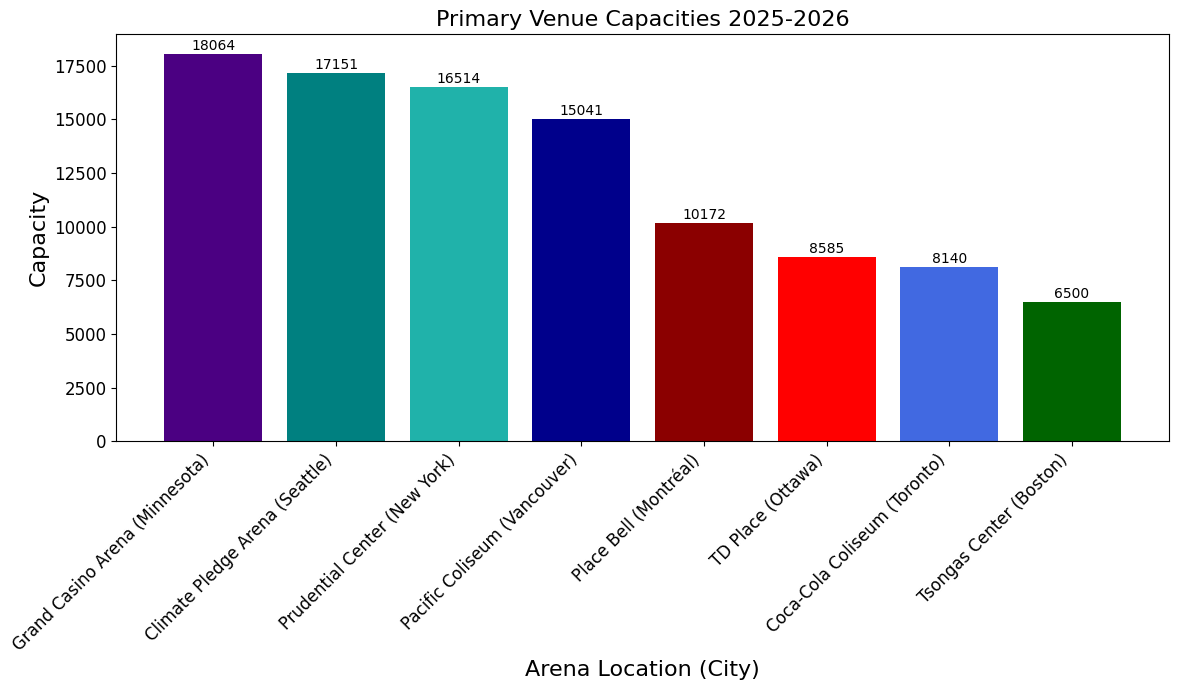

In [93]:
fig = plot_capacities(s3_arena_capacities_df)

In [94]:
fig.savefig('graphs/Primary Venue Capacities 2025-2026.png', dpi=300, bbox_inches='tight')

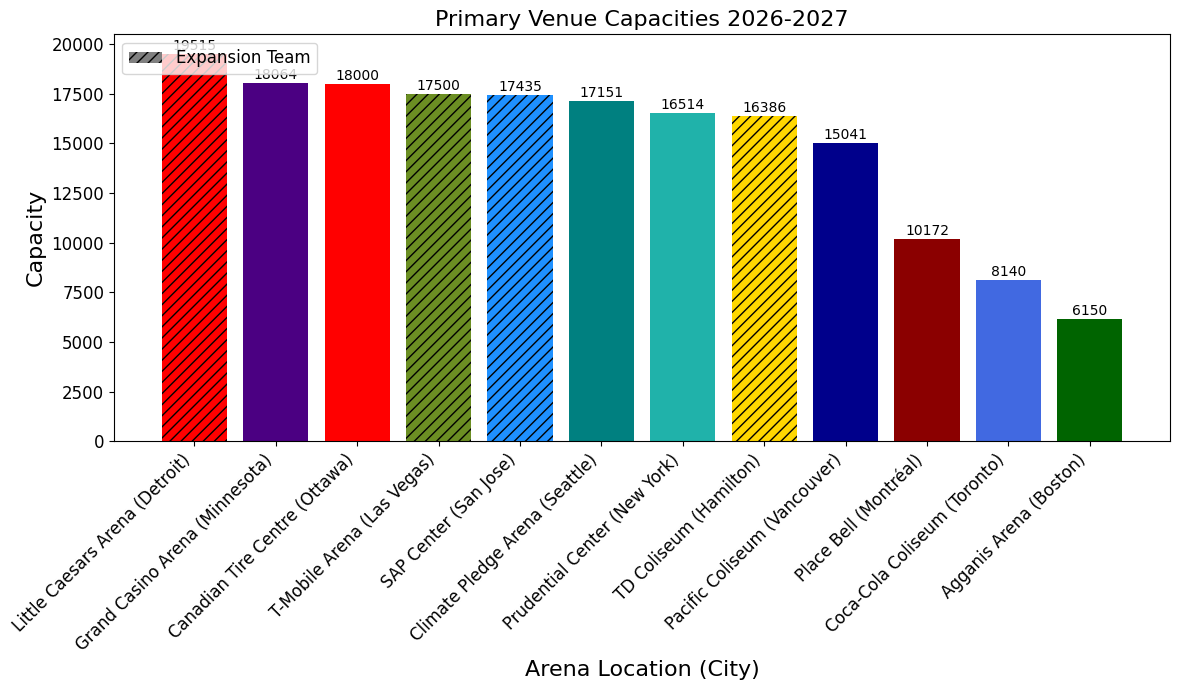

In [95]:
fig = plot_capacities(s4_arena_capacities_df, title='Primary Venue Capacities 2026-2027', show_expansion_teams=True)

In [96]:
fig.savefig('graphs/Primary Venue Capacities 2026-2027.png', dpi=300, bbox_inches='tight')

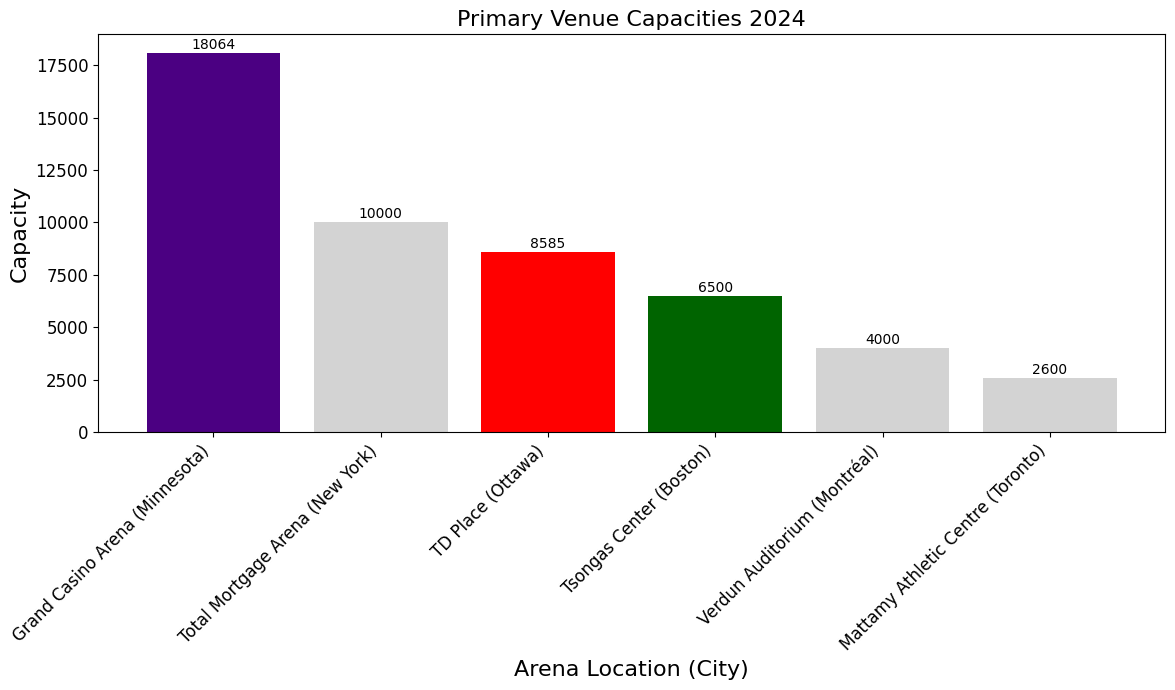

In [106]:
fig = plot_capacities(s1_arena_capacities_df, title='Primary Venue Capacities 2024', show_expansion_teams=False)

In [98]:
fig.savefig('graphs/Primary Venue Capacities 2024.png', dpi=300, bbox_inches='tight')

# Ottawa Charge Lansdowne 2.0

The arena, run by the Ottawa Sports and Entertainment Group (OSEG), is in its final years and a new arena with a seating capacity of 5,850, which can be expanded to more than 6,600 is currently under construction.

https://www.sportsnet.ca/pwhl/article/ottawa-charge-shifts-home-arena-to-canadian-tire-centre-home-of-senators/

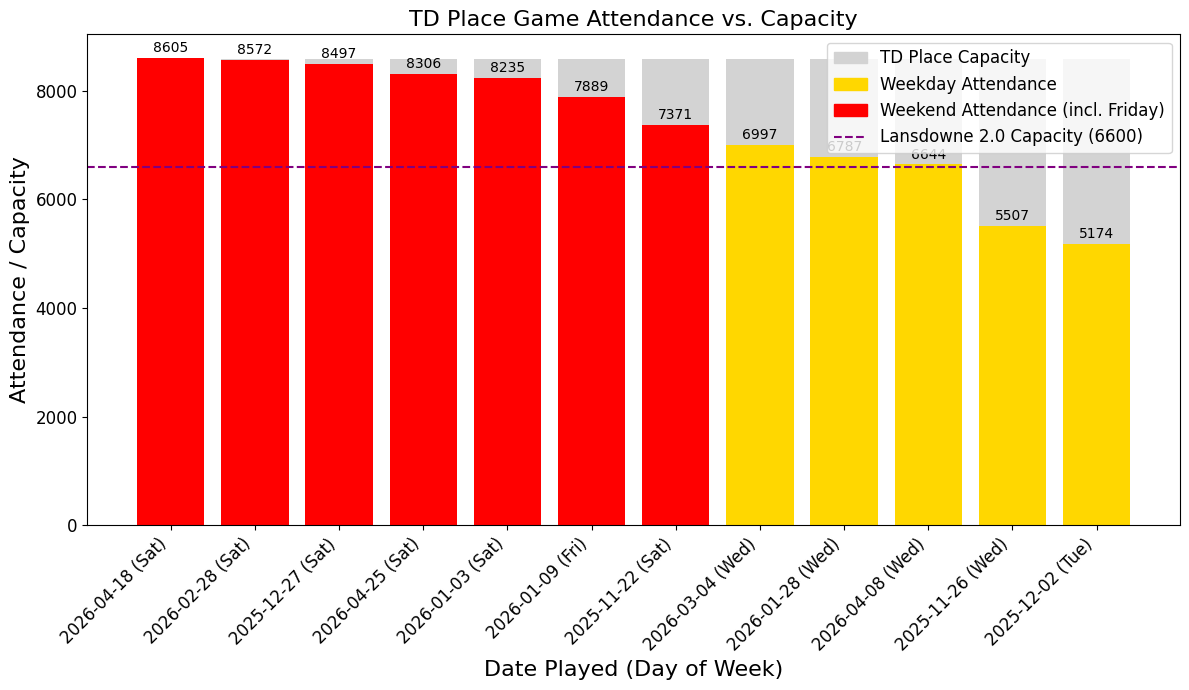

In [99]:
arena_name = "TD Place"
fig, ax, base_legend_patches = plot_arena_attendance_vs_capacity(arena_name, s3_regular_season_primary_venue_attendance_data, all_arena_capacities_df, location_name_color_map[arena_name], show_playoff_shading=False)

# Add the horizontal line for visualization only, without a label
ax.axhline(y=6600, color='purple', linestyle='--')

# Manually create a Line2D object for the Lansdowne 2.0 Capacity legend entry
from matplotlib.lines import Line2D
lansdowne_legend_line = Line2D([0], [0], color='purple', linestyle='--', label='Lansdowne 2.0 Capacity (6600)')

# Combine the base legend patches with the new manual line handle in the desired order
# base_legend_patches already contains: [TD Place Capacity, Weekday Attendance, Weekend Attendance (incl. Friday)]
combined_handles = base_legend_patches + [lansdowne_legend_line]

# Get labels from all handles to ensure correct display
combined_labels = [h.get_label() for h in combined_handles]

# Create the legend with all combined handles and labels
ax.legend(handles=combined_handles, labels=combined_labels, fontsize=12)

# Ensure tight layout
fig.tight_layout()

In [100]:
fig.savefig('graphs/Lansdowne 2.0.png', dpi=300, bbox_inches='tight')

In [101]:
td_place_games = s3_regular_season_attendance_data[s3_regular_season_attendance_data["location_name"] == arena_name]

In [102]:
len(td_place_games)

12

In [103]:
td_place_games['attendance'].mean()

np.float64(7382.0)

# Walk Score

In [117]:
s4_walk_score_df = pd.read_csv('/content/drive/My Drive/arena characteristics/s4_arena_walk_score.csv')

s4_walk_score_df.head()

,location_name,city,walk_score
0,Climate Pledge Arena,Seattle,97
1,Coca-Cola Coliseum,Toronto,72
2,Grand Casino Arena,Minnesota,90
3,Pacific Coliseum,Vancouver,83
4,Place Bell,Montréal,80


In [113]:
import matplotlib.pyplot as plt

def plot_walk_score(walk_score_df, title='Arena Walk Score'):
    # Prepare data for plotting
    df = walk_score_df.copy()

    # Map colors based on the second color in the tuple from location_name_color_map
    df['color'] = df['location_name'].map(lambda x: location_name_color_map.get(x, ('gray', 'lightgray'))[1])

    # Create a combined label for location and city
    df['display_label'] = df.apply(lambda row: f"{row['location_name']} ({row['city']})", axis=1)

    # Sort by walk_score for better visualization
    df_sorted = df.sort_values(by='walk_score', ascending=False)

    fig, ax = plt.subplots(figsize=(12, 7))

    bars = ax.bar(
        df_sorted['display_label'],
        df_sorted['walk_score'],
        color=df_sorted['color']
    )

    # Add walk score numbers on top of the bars
    for bar in bars:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            yval + 1, # Adjusted offset for walk scores
            int(yval),
            ha='center',
            va='bottom',
            fontsize=10
        )

    ax.set_xlabel('Arena Location (City)', fontsize=16)
    ax.set_ylabel('Walk Score', fontsize=16)
    ax.set_title(title, fontsize=16)
    ax.set_xticks(range(len(df_sorted['display_label'])))
    ax.set_xticklabels(df_sorted['display_label'], rotation=45, ha='right', fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    plt.tight_layout()
    return fig

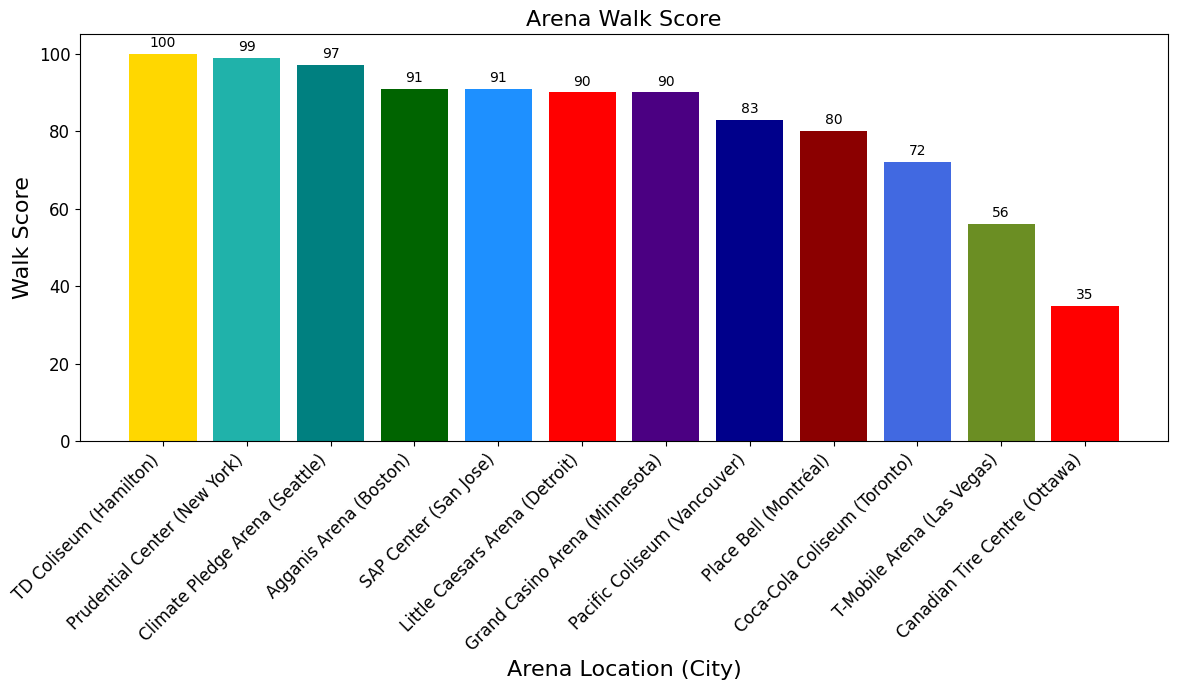

In [118]:
fig = plot_walk_score(s4_walk_score_df)